# **1) Title and Introduction**

# Customer Segmentation and Churn Prediction Using Machine Learning

## Project Overview
This project applies machine learning to solve two important business problems:

### Part A: Customer Segmentation
Customer segmentation groups customers into meaningful clusters based on purchasing behavior.  
This helps businesses understand different customer types and design personalized marketing strategies.

### Part B: Churn Prediction
Churn prediction identifies customers who are likely to leave a company.  
This helps businesses take proactive actions to improve customer retention.

## Why this project is important
Both segmentation and churn prediction are key areas in customer analytics.

- Segmentation helps answer: **Who are our customers?**
- Churn prediction helps answer: **Which customers are at risk of leaving?**

Together, these analyses help businesses understand customer behavior and improve decision-making.

## Project Objectives
- Perform customer segmentation using an E-commerce dataset
- Build a churn prediction model using a Telco customer dataset
- Compare different machine learning models
- Explain the main business insights from both tasks
- Provide recommendations for customer retention and marketing strategy

# **2) Import Libraries**

## Import Libraries

This section imports all the required libraries for:
- data handling
- visualization
- preprocessing
- clustering
- classification
- model evaluation

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time
from datetime import datetime

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Train-test split and tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Nice plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# **PART A — CUSTOMER SEGMENTATION**

# **3) Load E-commerce Dataset**

# Part A: Customer Segmentation

## Load E-commerce Dataset

In this section, we load the E-commerce dataset that contains customer transaction records.
This dataset will be used for customer segmentation.

In [3]:
ecom = pd.read_csv("/content/data.csv", encoding="ISO-8859-1")

print("E-commerce dataset shape:", ecom.shape)
ecom.head()

E-commerce dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **4) Understand the Dataset**

## Initial Data Understanding

We inspect the dataset structure, column names, data types, and missing values.

In [4]:
# Check columns
ecom.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [5]:
# Dataset information
ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# Statistical summary
ecom.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values
ecom.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
# Duplicate rows
print("Duplicate rows:", ecom.duplicated().sum())

Duplicate rows: 5268


# **5) Data Cleaning**

## Data Cleaning

For customer segmentation, we need clean transaction data.

We will:
- remove missing customer IDs
- remove duplicate rows
- remove cancelled transactions
- remove invalid quantity and price values
- create a sales amount column

In [9]:
ecom_clean = ecom.copy()

# Remove rows with missing CustomerID
ecom_clean = ecom_clean.dropna(subset=["CustomerID"])

# Remove duplicates
ecom_clean = ecom_clean.drop_duplicates()

# Remove cancelled transactions (InvoiceNo starts with 'C')
ecom_clean = ecom_clean[~ecom_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Remove rows with non-positive quantity or unit price
ecom_clean = ecom_clean[(ecom_clean["Quantity"] > 0) & (ecom_clean["UnitPrice"] > 0)]

# Convert CustomerID to string for consistency
ecom_clean["CustomerID"] = ecom_clean["CustomerID"].astype(str)

# Convert InvoiceDate to datetime
ecom_clean["InvoiceDate"] = pd.to_datetime(ecom_clean["InvoiceDate"])

# Create Sales column
ecom_clean["Sales"] = ecom_clean["Quantity"] * ecom_clean["UnitPrice"]

print("Cleaned dataset shape:", ecom_clean.shape)
ecom_clean.head()

Cleaned dataset shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# **6) Exploratory Data Analysis**

## Exploratory Data Analysis (EDA)

We explore customer purchase behavior using:
- country distribution
- sales distribution
- quantity distribution
- top customers by spending

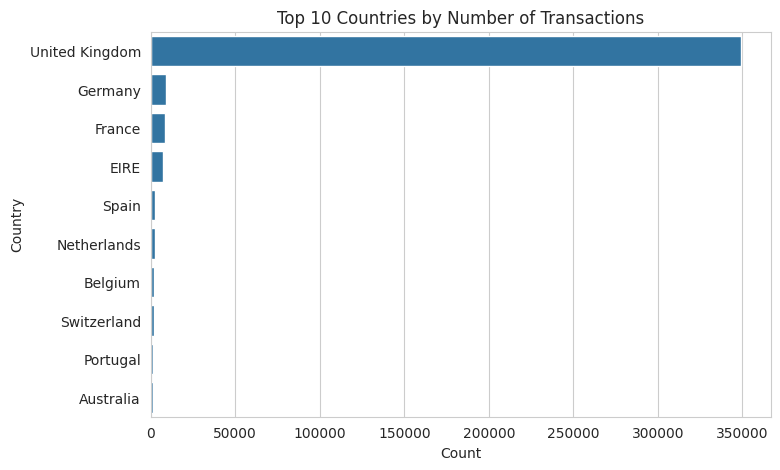

In [10]:
# Top countries by number of transactions
top_countries = ecom_clean["Country"].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

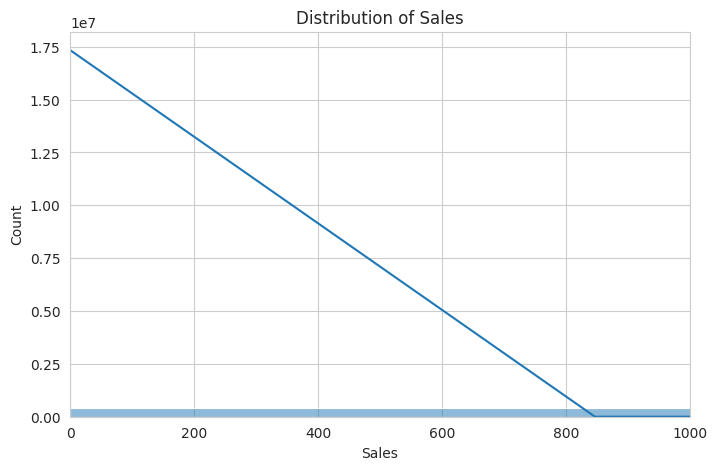

In [11]:
# Distribution of sales
sns.histplot(ecom_clean["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlim(0, 1000)
plt.show()

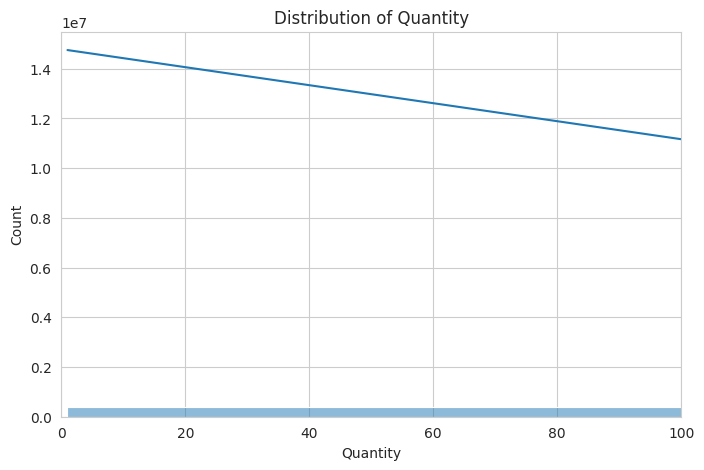

In [12]:
# Distribution of quantity
sns.histplot(ecom_clean["Quantity"], bins=50, kde=True)
plt.title("Distribution of Quantity")
plt.xlim(0, 100)
plt.show()

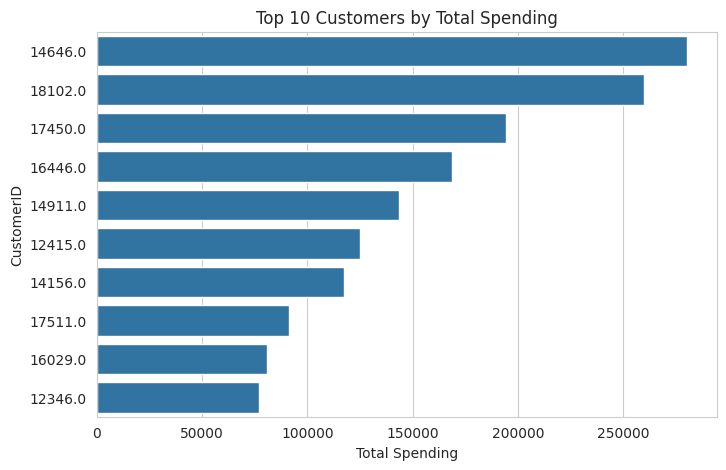

In [13]:
# Top 10 customers by total spending
top_customers = ecom_clean.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("CustomerID")
plt.show()

# **7) RFM Feature Engineering**

## RFM Feature Engineering

RFM stands for:
- **Recency**: how recently the customer purchased
- **Frequency**: how often the customer purchased
- **Monetary**: how much the customer spent

These are commonly used features for customer segmentation.

In [35]:
# Set reference date as one day after the latest transaction
reference_date = ecom_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = ecom_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,   # Recency
    "InvoiceNo": "nunique",                                     # Frequency
    "Sales": "sum"                                              # Monetary
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

print("RFM shape:", rfm.shape)
rfm.head()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


# **8) Explore RFM Features**

## Explore RFM Features

We inspect the distributions of recency, frequency, and monetary value.

In [36]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


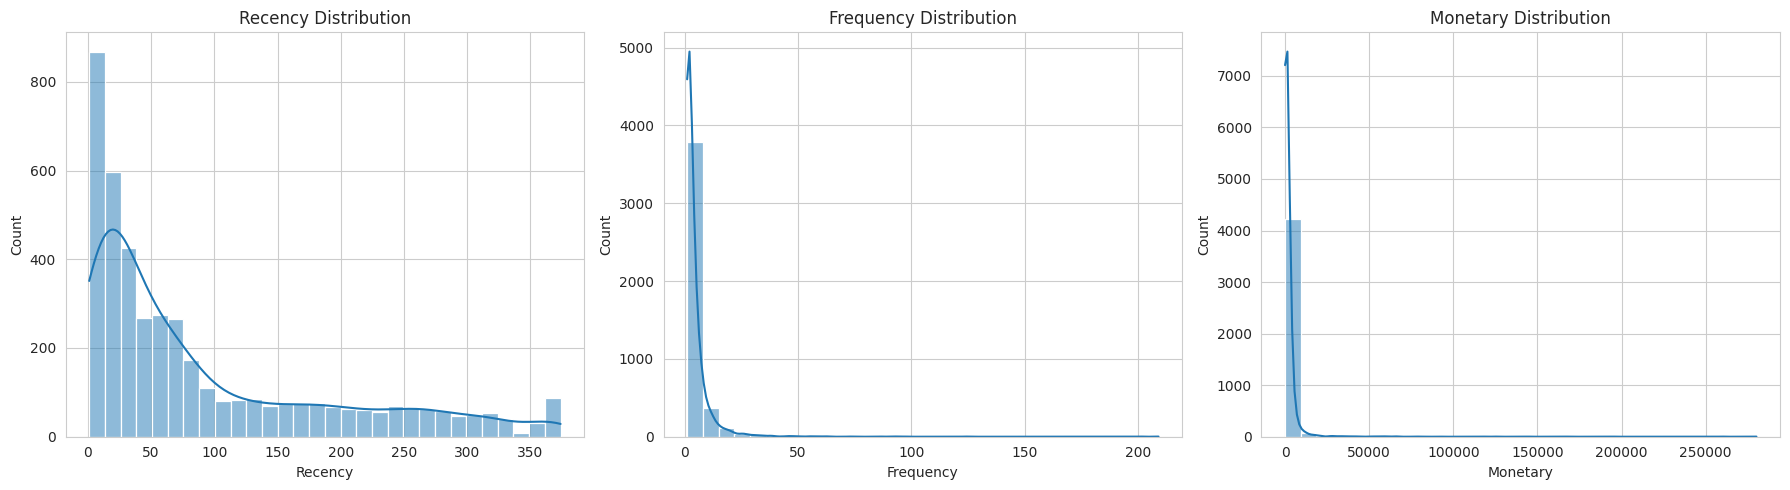

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0], kde=True)
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1], kde=True)
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2], kde=True)
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

# **9) Handle Skewness**

## Log Transformation

Frequency and Monetary are often highly skewed.
We apply log transformation to make the data more suitable for clustering.

In [38]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,5.789960,0.693147,11.253955
1,12347.0,1.098612,2.079442,8.368925
2,12348.0,4.330733,1.609438,7.494564
3,12349.0,2.995732,0.693147,7.472245
4,12350.0,5.739793,0.693147,5.815324


# **10) Standardize the Data**

## Feature Scaling

K-Means clustering is distance-based, so scaling is required.

In [39]:
rfm_features = rfm_log[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

# **11) Elbow Method and Silhouette Score**

## Choosing the Optimal Number of Clusters

We use:
- Elbow Method
- Silhouette Score

These help determine the best number of customer segments.

In [40]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

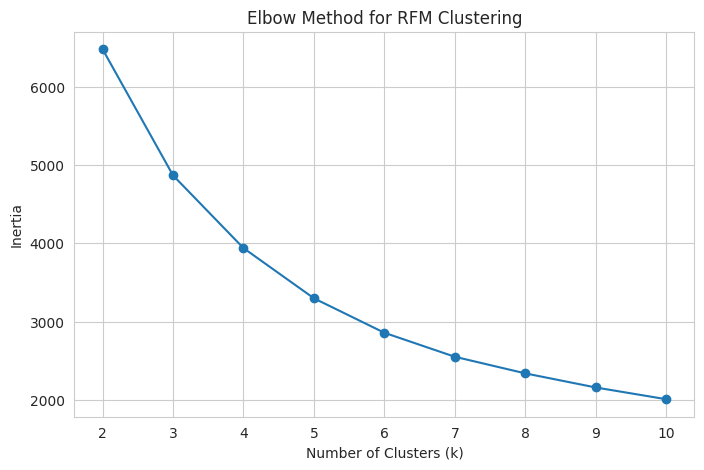

In [41]:
# Elbow plot
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for RFM Clustering")
plt.show()

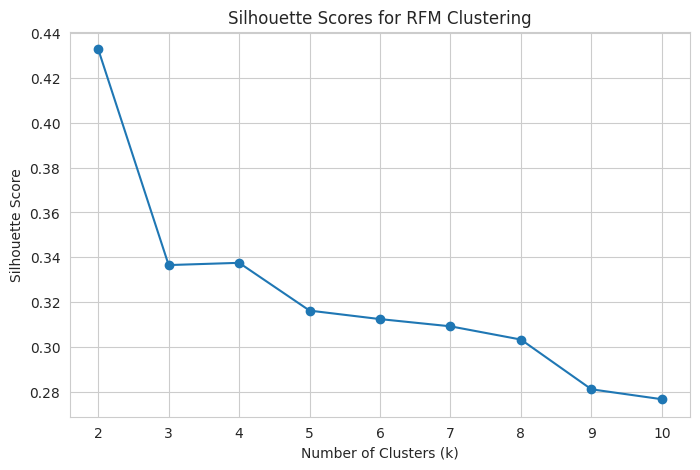

Best k based on silhouette score: 2


In [42]:
# Silhouette score plot
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for RFM Clustering")
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print("Best k based on silhouette score:", best_k)

### Choosing the Optimal Number of Clusters

Two methods were used to determine the optimal number of clusters:

• Elbow Method  
• Silhouette Score

The Silhouette Score reached its highest value at **k = 2**, indicating strong separation between two broad customer groups.

However, customer segmentation in business applications often benefits from more detailed and actionable customer groups. When examining **k = 3**, the clusters revealed three meaningful customer segments:

- **VIP / High-Value Customers** – customers with very high spending and frequent purchases  
- **Regular Customers** – customers with moderate purchasing behavior  
- **Low-Value / At-Risk Customers** – customers with low spending and infrequent purchases  

Although k = 2 provides the strongest mathematical separation, **k = 3 was selected because it produces more interpretable and actionable customer segments** for marketing and business strategy.

Therefore, **k = 3 was chosen as the final number of clusters.**

# **12) Apply K-Means Clustering**

## K-Means Clustering

Now we apply K-Means using the selected number of clusters.

In [43]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,1


# **13) PCA Visualization**

## PCA Visualization

We reduce the RFM data to 2 dimensions for visualization.

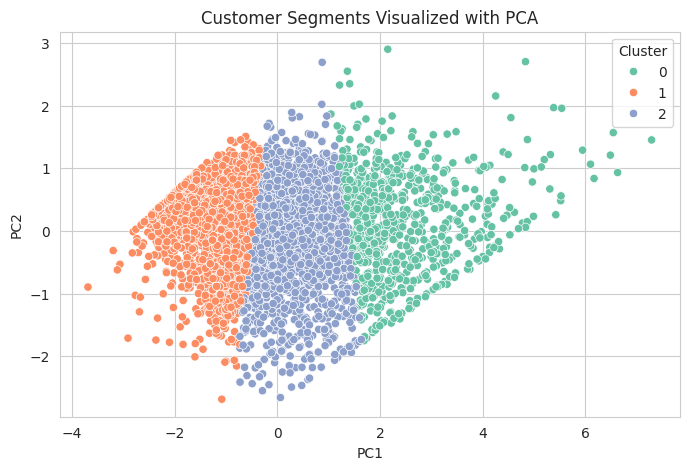

In [44]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(rfm_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = rfm["Cluster"]

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title("Customer Segments Visualized with PCA")
plt.show()

# **14) Cluster Profiling**

## Cluster Profiling

This section summarizes the average Recency, Frequency, and Monetary values for each cluster.

In [45]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_profile["CustomerCount"] = rfm["Cluster"].value_counts().sort_index()

cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,17.06,13.35,7898.46,769
1,167.36,1.35,361.00,1872
2,44.20,3.38,1259.58,1697


# **15) Segment Naming**

## Segment Naming

Based on the RFM profile, each cluster is assigned a business-friendly segment name.
You should adjust the labels after checking the cluster profile table.

In [46]:
# Update these names after reviewing your cluster profile
segment_labels = {
    0: "High-Value Customers",
    1: "Regular Customers",
    2: "Low-Value Customers",
    3: "New Customers"
}

rfm["SegmentName"] = rfm["Cluster"].map(segment_labels).fillna("Other Segment")

rfm[["Cluster", "SegmentName"]].drop_duplicates().sort_values("Cluster")

,Cluster,SegmentName
1,0,High-Value Customers
4,1,Regular Customers
0,2,Low-Value Customers


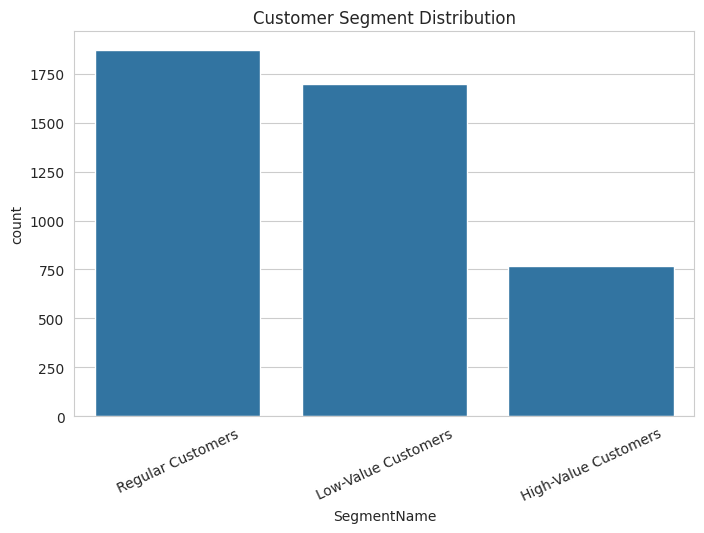

In [47]:
sns.countplot(x="SegmentName", data=rfm, order=rfm["SegmentName"].value_counts().index)
plt.title("Customer Segment Distribution")
plt.xticks(rotation=25)
plt.show()

# **PART B — CHURN PREDICTION**

# **16) Load Telco Dataset**

# Part B: Churn Prediction

## Load Telco Dataset

This dataset contains customer demographics, contract information, service usage, billing information, and churn status.

In [48]:
telco = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Telco dataset shape:", telco.shape)
telco.head()

Telco dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **17) Initial Data Understanding**

## Initial Data Understanding

We inspect the structure, columns, and missing values in the Telco dataset.

In [49]:
telco.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [50]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
telco.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [53]:
print("Duplicate rows:", telco.duplicated().sum())

Duplicate rows: 0


# **18) Data Cleaning**

## Data Cleaning

We clean the Telco dataset by:
- removing the customer ID column
- converting TotalCharges to numeric
- handling missing values

In [54]:
telco_data = telco.copy()

# Drop ID column
telco_data.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
telco_data["TotalCharges"] = pd.to_numeric(telco_data["TotalCharges"], errors="coerce")

# Fill missing values with median
telco_data["TotalCharges"].fillna(telco_data["TotalCharges"].median(), inplace=True)

print("Shape after cleaning:", telco_data.shape)
telco_data.isnull().sum()

Shape after cleaning: (7043, 20)


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


# **19) Exploratory Data Analysis**

## Exploratory Data Analysis (EDA)

We explore:
- churn distribution
- numerical features
- categorical variables vs churn

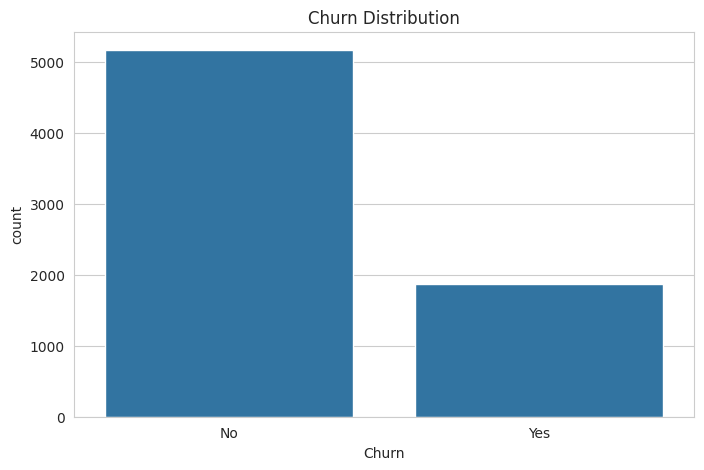

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [55]:
sns.countplot(x="Churn", data=telco_data)
plt.title("Churn Distribution")
plt.show()

print(telco_data["Churn"].value_counts())
print("\nPercentage distribution:")
print(telco_data["Churn"].value_counts(normalize=True) * 100)

In [56]:
num_cols = telco_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

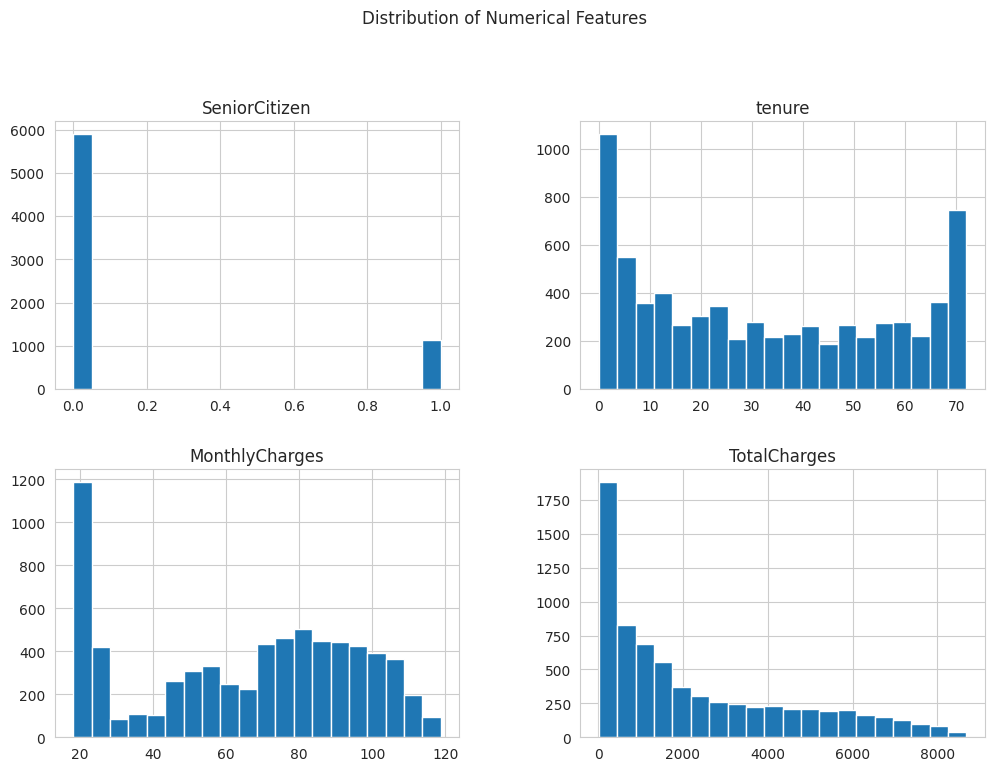

In [57]:
telco_data[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.show()

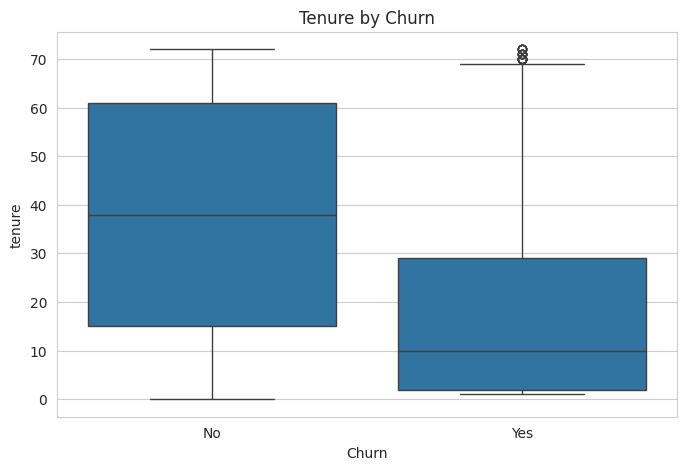

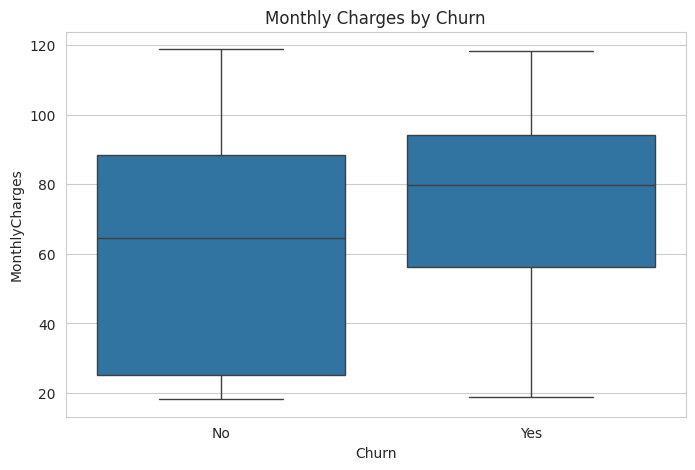

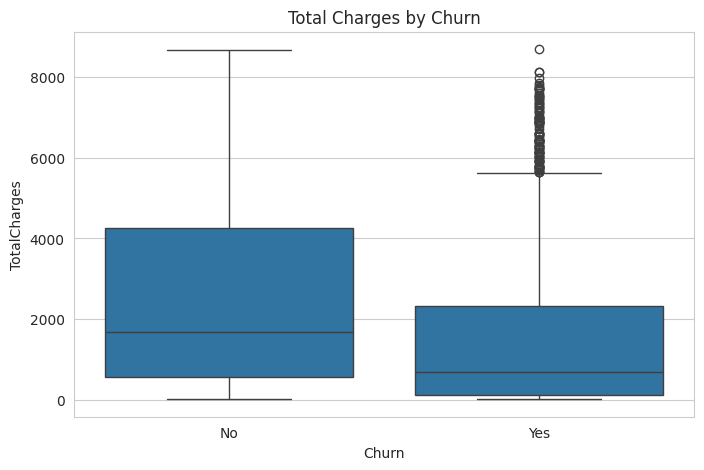

In [58]:
sns.boxplot(x="Churn", y="tenure", data=telco_data)
plt.title("Tenure by Churn")
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=telco_data)
plt.title("Monthly Charges by Churn")
plt.show()

sns.boxplot(x="Churn", y="TotalCharges", data=telco_data)
plt.title("Total Charges by Churn")
plt.show()

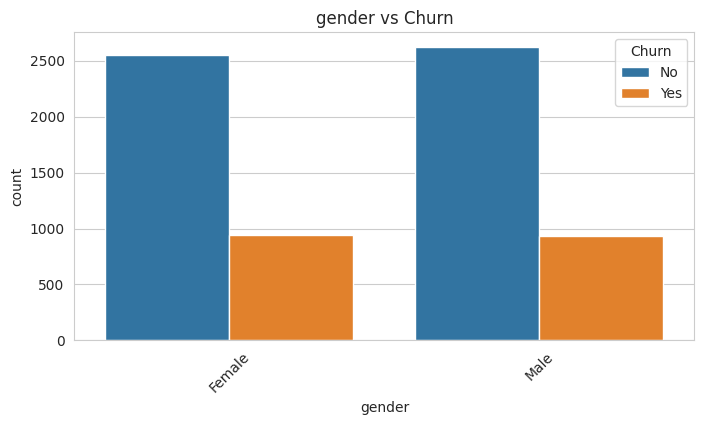

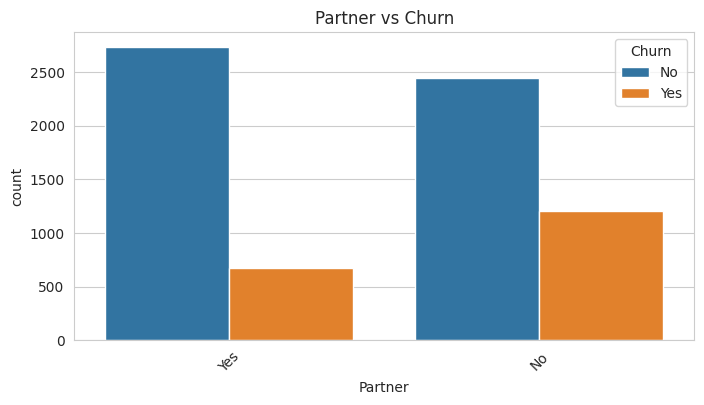

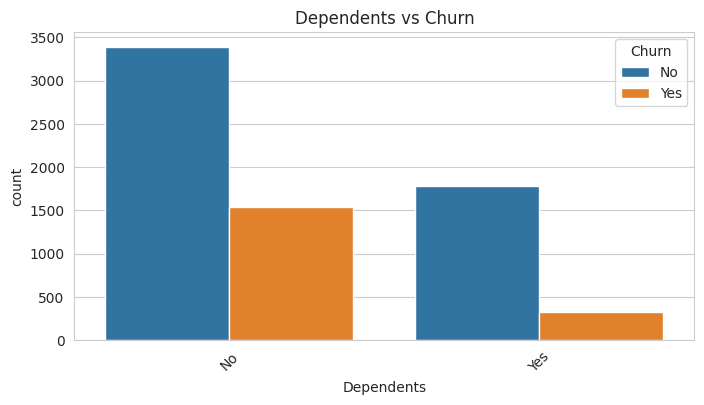

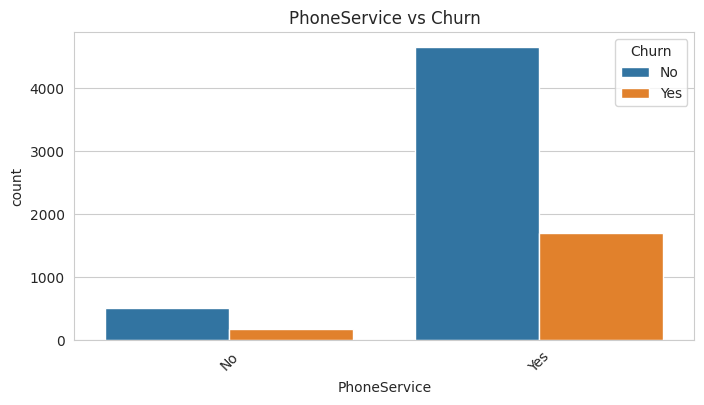

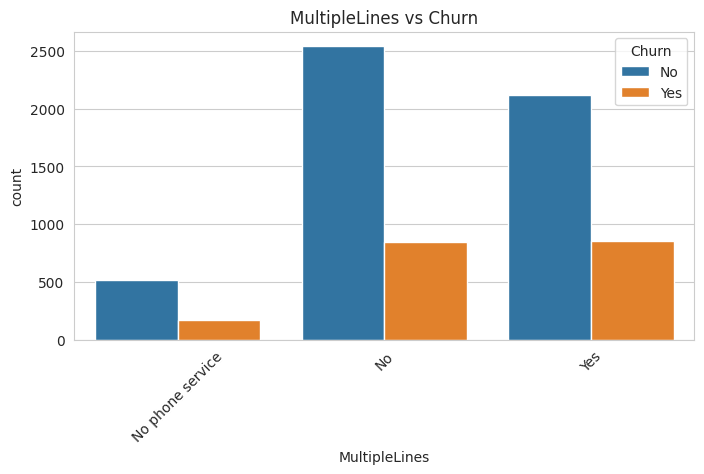

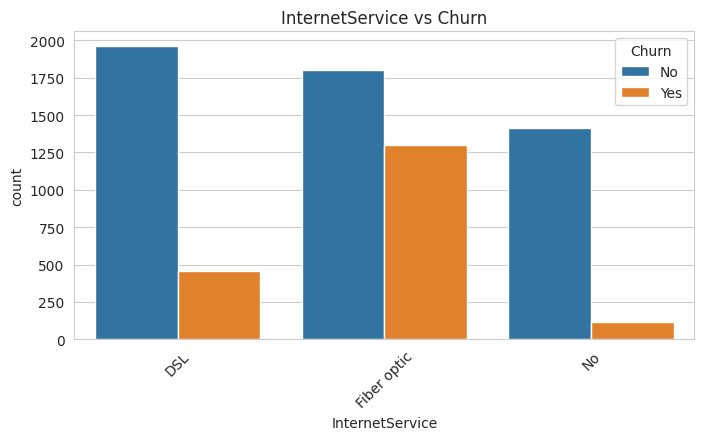

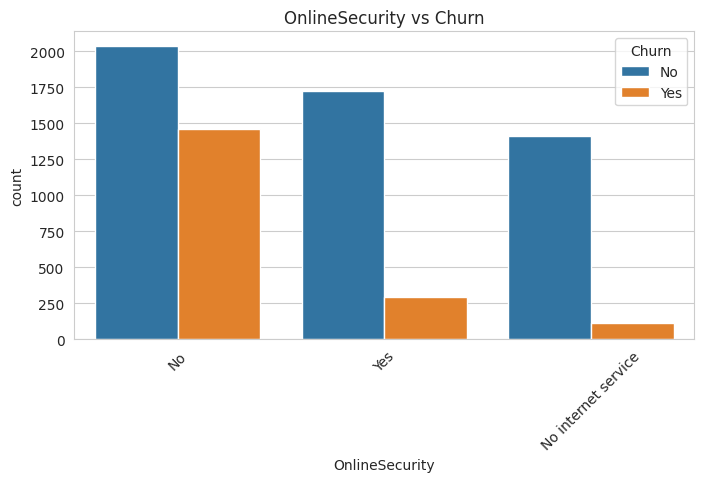

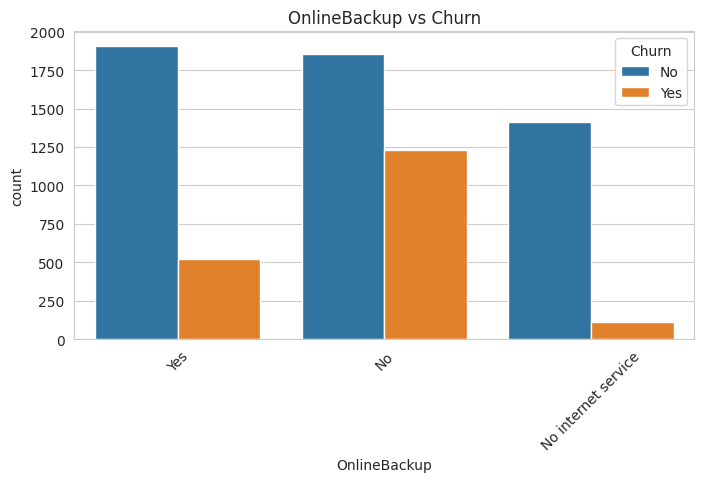

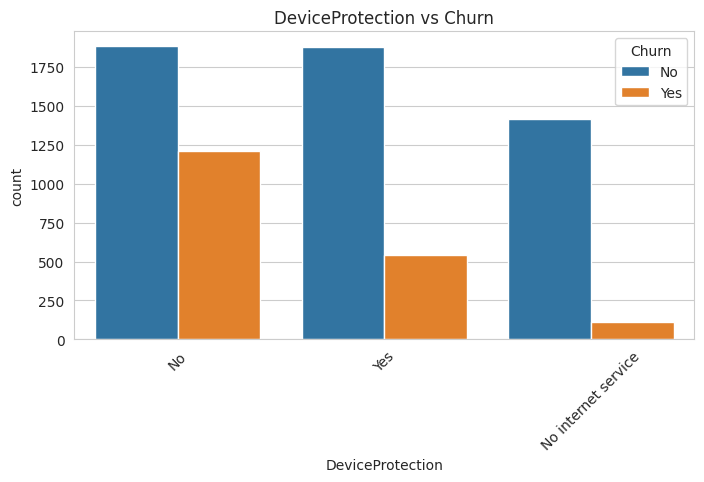

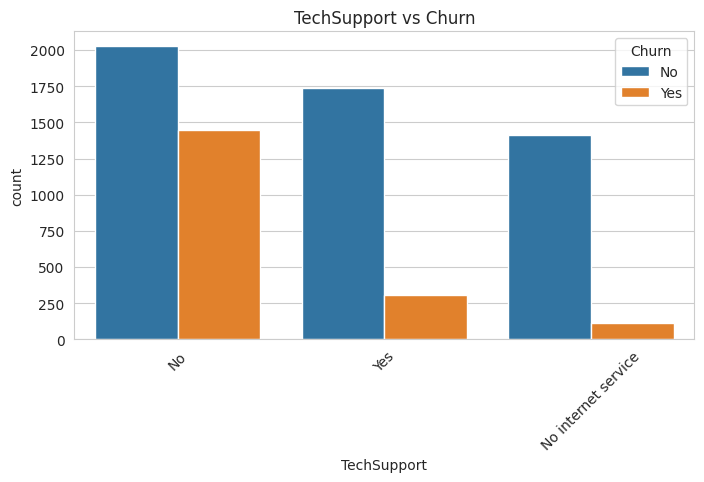

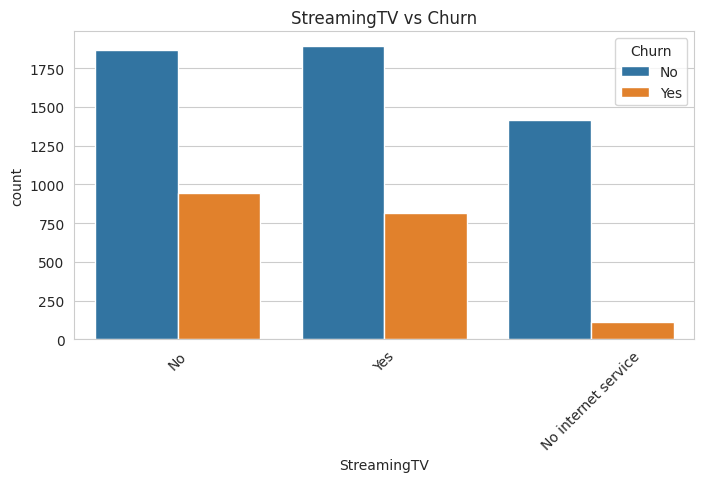

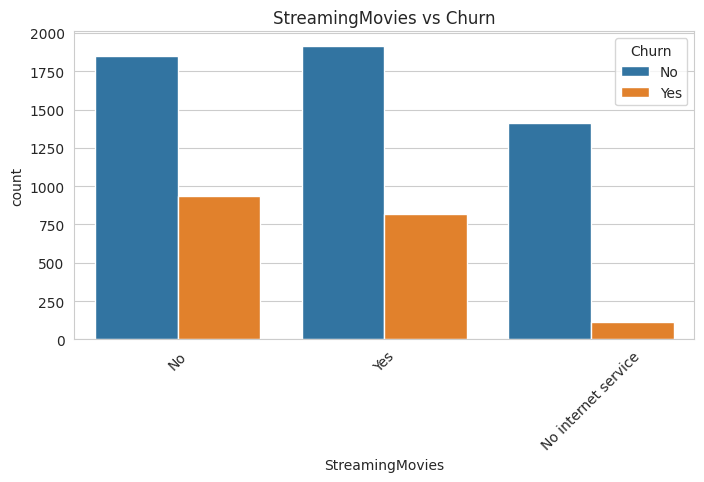

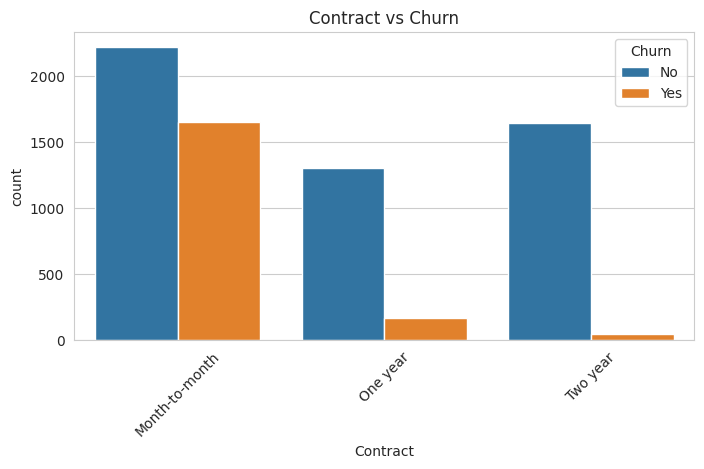

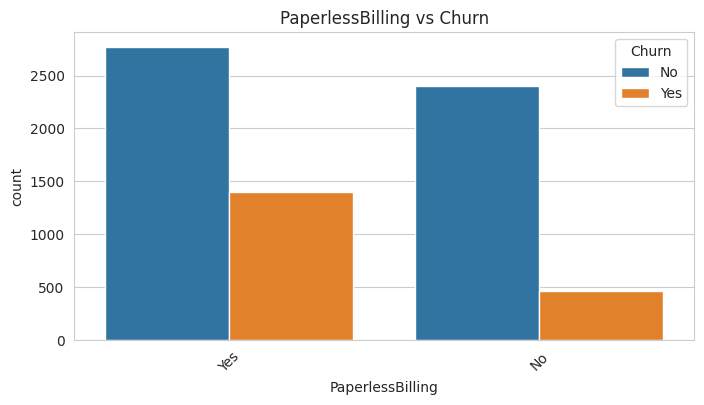

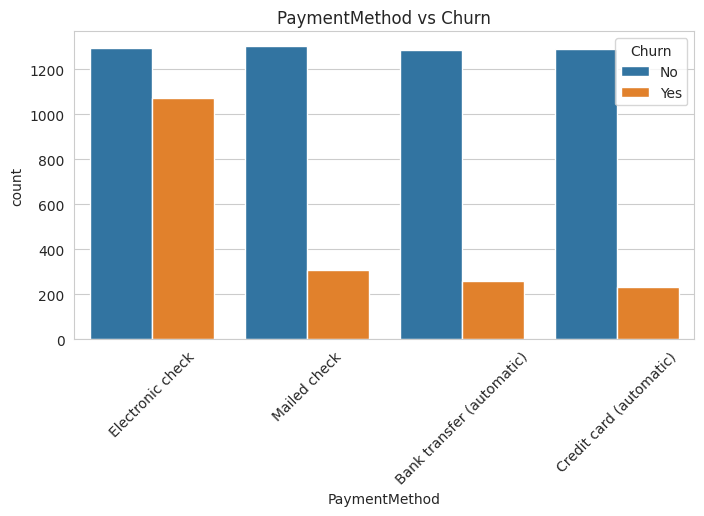

In [59]:
cat_cols = telco_data.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove("Churn")

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="Churn", data=telco_data)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

# **20) Feature Engineering**

## Feature Engineering

We create additional features that may improve churn prediction.

In [60]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 24:
        return "13-24 Months"
    elif tenure <= 48:
        return "25-48 Months"
    else:
        return "49+ Months"

telco_data["TenureGroup"] = telco_data["tenure"].apply(tenure_group)

In [61]:
service_cols = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] not in ["No", "No internet service", "No phone service"]:
            count += 1
    return count

telco_data["NumServices"] = telco_data.apply(count_services, axis=1)

In [62]:
telco_data["AvgMonthlySpendApprox"] = telco_data["TotalCharges"] / (telco_data["tenure"] + 1)

telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumServices,AvgMonthlySpendApprox
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,2,14.925000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,4,53.985714
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,4,36.050000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months,4,40.016304
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,2,50.550000


# **21) Prepare Data for Modeling**

## Prepare Data for Churn Prediction

We:
- encode the target variable
- split the data
- create preprocessing pipelines

In [63]:
model_data = telco_data.copy()

# Encode target
model_data["Churn"] = model_data["Churn"].map({"No": 0, "Yes": 1})

X = model_data.drop("Churn", axis=1)
y = model_data["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


In [64]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 22)
Test size: (1409, 22)


In [65]:
# Separate numerical and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlySpendApprox']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [66]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# **22) Handle Class Imbalance**

## Handle Class Imbalance with SMOTE

The churn dataset is imbalanced, so we use SMOTE on the training data.

In [67]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


# **23) Train Multiple Models**

## Train Churn Prediction Models

We train three machine learning models:
- Logistic Regression
- Random Forest
- Gradient Boosting

In [68]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [69]:
results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.746629,0.514834,0.788770,0.623020,0.844902
2,Gradient Boosting,0.777147,0.569124,0.660428,0.611386,0.841630
1,Random Forest,0.775018,0.581662,0.542781,0.561549,0.821487


# **24) Detailed Evaluation**

## Detailed Evaluation

For each model, we display:
- confusion matrix
- classification report
- ROC curve

MODEL: Logistic Regression


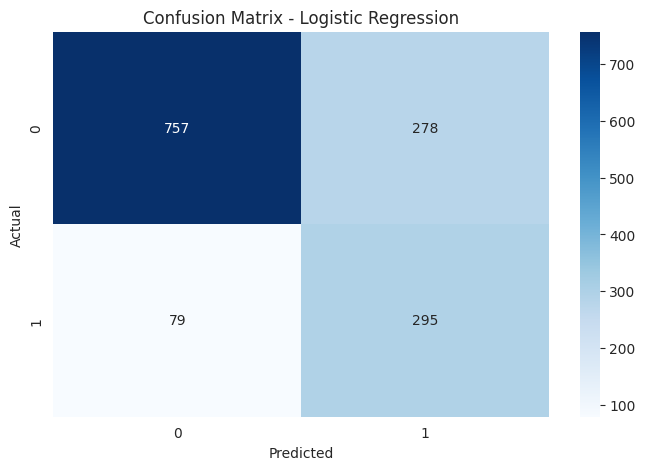

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



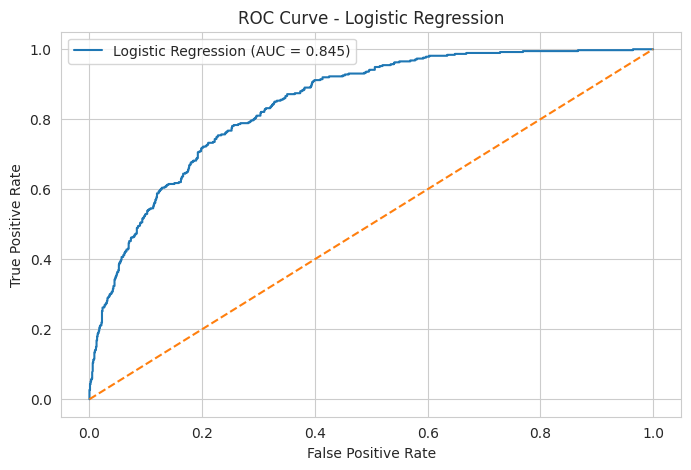

MODEL: Random Forest


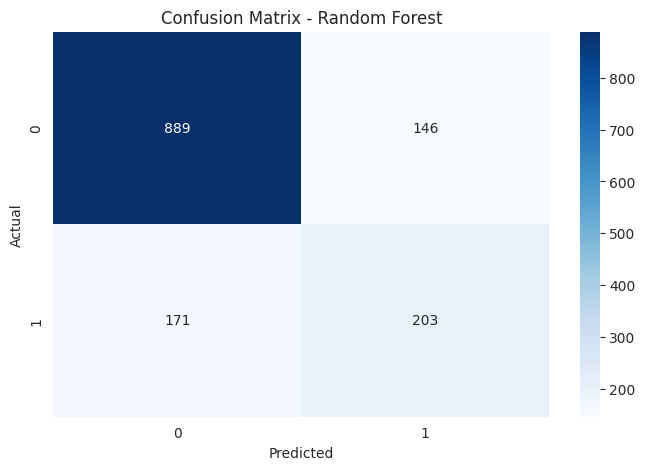

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1035
           1       0.58      0.54      0.56       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409



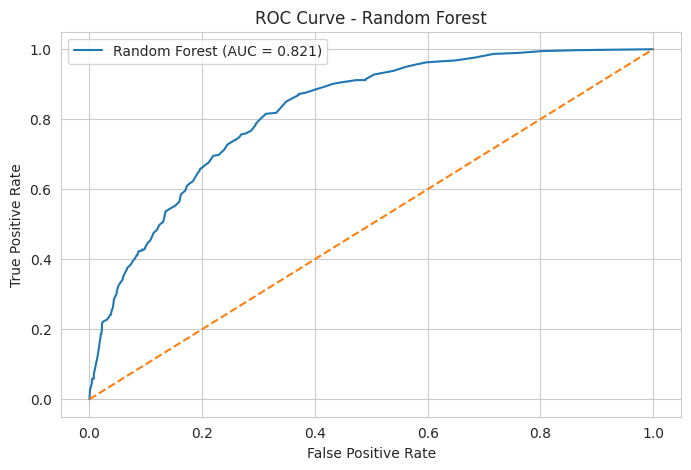

MODEL: Gradient Boosting


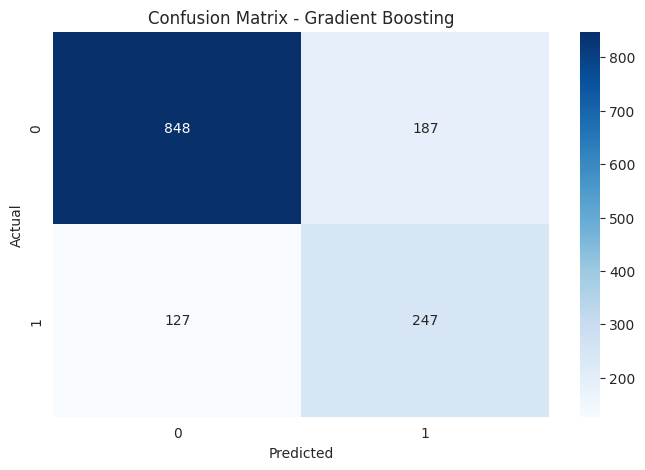

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



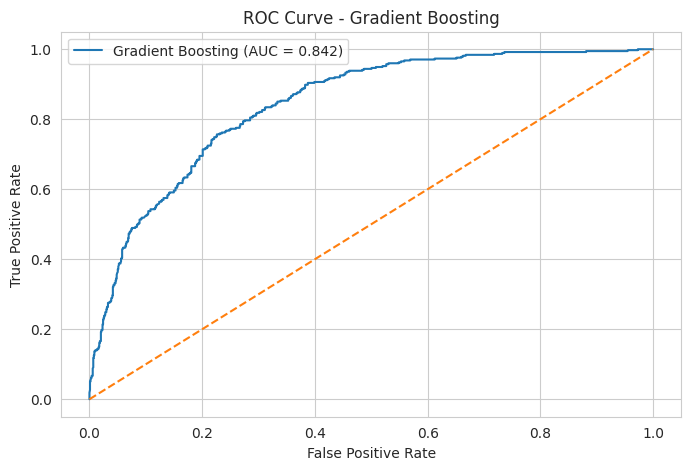

In [70]:
for name, model in models.items():
    print("=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification report
    print(classification_report(y_test, y_pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

# **25) Select the Final Model**

## Select the Final Model

The final model is selected based on overall classification performance, with special attention to ROC-AUC and model interpretability.

In [71]:
best_model_name = "Logistic Regression"
best_model = models[best_model_name]

print("Final model selected:", best_model_name)
results_df

Final model selected: Logistic Regression


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.746629,0.514834,0.788770,0.623020,0.844902
2,Gradient Boosting,0.777147,0.569124,0.660428,0.611386,0.841630
1,Random Forest,0.775018,0.581662,0.542781,0.561549,0.821487


# **26) Hyperparameter Tuning**

## Hyperparameter Tuning

We tune the selected model using GridSearchCV.

In [72]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train_resampled, y_train_resampled)

tuned_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best parameters: {'C': 10, 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8559653884999571


In [73]:
# Evaluate tuned model
y_pred_tuned = tuned_model.predict(X_test_processed)
y_prob_tuned = tuned_model.predict_proba(X_test_processed)[:, 1]

print("Tuned Model Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Tuned Model Performance
Accuracy : 0.7459190915542938
Precision: 0.5139372822299652
Recall   : 0.7887700534759359
F1 Score : 0.6223628691983122
ROC-AUC  : 0.844441861065902


# **27) Feature Importance / Coefficients**

## Feature Interpretation

Since the final model is Logistic Regression, we examine the most influential coefficients.

In [74]:
feature_names = preprocessor.get_feature_names_out()

coefficients = tuned_model.coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
}).sort_values(by="AbsCoefficient", ascending=False)

importance_df.head(15)

,Feature,Coefficient,AbsCoefficient
5,num__AvgMonthlySpendApprox,-2.316421,2.316421
18,cat__InternetService_Fiber optic,1.098439,1.098439
17,cat__InternetService_DSL,-1.017759,1.017759
40,cat__Contract_Two year,-0.970971,0.970971
1,num__tenure,-0.966975,0.966975
38,cat__Contract_Month-to-month,0.776945,0.776945
4,num__NumServices,0.661608,0.661608
2,num__MonthlyCharges,-0.610343,0.610343
3,num__TotalCharges,0.514852,0.514852
21,cat__OnlineSecurity_No internet service,-0.344245,0.344245


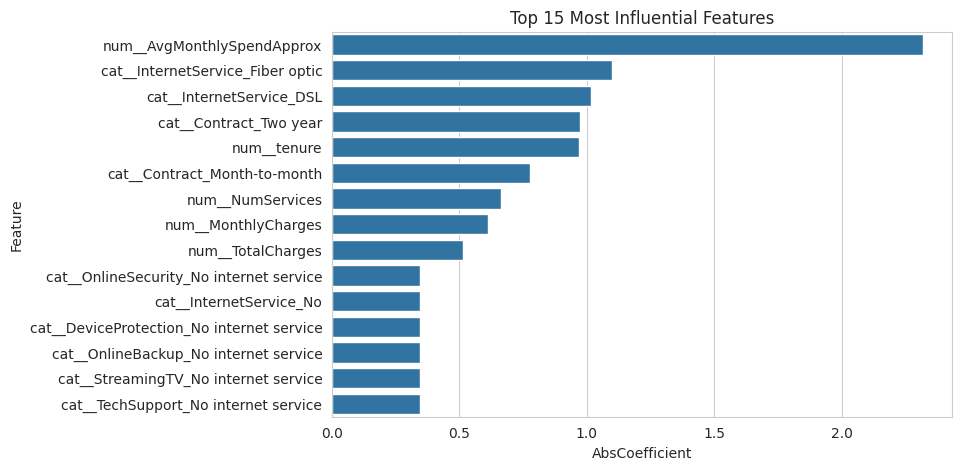

In [75]:
top_features = importance_df.head(15)

sns.barplot(x="AbsCoefficient", y="Feature", data=top_features)
plt.title("Top 15 Most Influential Features")
plt.show()

# **Linking Both Analyses**

Although the segmentation and churn analyses were performed using two different datasets, they address complementary business questions and together provide a more complete understanding of customer behavior.

Customer segmentation focuses on identifying groups of customers with similar purchasing behavior. In this project, RFM analysis (Recency, Frequency, Monetary) was used to represent how recently customers purchased, how often they purchase, and how much they spend. K-Means clustering was then applied to group customers into meaningful segments.

The clustering results identified three main customer segments:

• High-Value Customers – customers who purchase frequently and spend large amounts  
• Regular Customers – customers with moderate purchasing behavior  
• Low-Value Customers – customers who purchase infrequently and spend less

These segments help businesses understand the different types of customers they serve and allow them to design targeted marketing strategies.

On the other hand, churn prediction focuses on identifying customers who are likely to stop using a service. Using the Telco dataset, machine learning models were trained to predict whether a customer is likely to churn based on factors such as tenure, contract type, service usage, and billing information.

By combining insights from both analyses, businesses can better understand not only who their customers are but also which customers are most at risk of leaving.

For example:

• Low-value customers may have a higher risk of churn due to low engagement.  
• Regular customers may churn if competitors offer better services or pricing.  
• High-value customers must be carefully retained because they generate the most revenue.

Therefore, customer segmentation helps businesses understand customer groups, while churn prediction helps them identify customers who may leave. Together, these analyses support better decision-making and more effective customer relationship management.

# **Business Recommendations**

Based on the insights obtained from both customer segmentation and churn prediction, several important business recommendations can be made.

### 1. Retain High-Value Customers

High-value customers contribute significantly to company revenue and show high purchasing frequency. Businesses should prioritize retaining these customers by offering:

• loyalty programs  
• exclusive promotions  
• personalized recommendations  
• premium customer support  

Maintaining strong relationships with these customers ensures long-term profitability.

### 2. Increase Engagement of Regular Customers

Regular customers represent a large portion of the customer base but have moderate spending levels. Businesses can increase their value by encouraging more frequent purchases through:

• targeted marketing campaigns  
• cross-selling and upselling strategies  
• personalized product recommendations  

These strategies can help move regular customers into the high-value segment.

### 3. Re-engage Low-Value Customers

Customers in the low-value segment purchase less frequently and generate lower revenue. These customers may also be at higher risk of churn.

Businesses can attempt to re-engage these customers using:

• limited-time discounts  
• email marketing campaigns  
• promotional offers  

The objective is to increase their engagement and purchasing activity.

### 4. Use Churn Prediction for Early Intervention

The churn prediction model allows businesses to identify customers who are likely to leave the service. Early identification allows companies to implement proactive retention strategies such as:

• special retention offers  
• improved customer support  
• addressing service complaints quickly  

Preventing churn can significantly reduce revenue loss.

### 5. Implement Data-Driven Marketing Strategies

Combining customer segmentation with churn prediction enables companies to implement more effective marketing strategies.

For example:

• Targeting high-value customers with loyalty rewards  
• Offering retention campaigns to customers with high churn probability  
• Providing personalized promotions based on purchasing behavior

These strategies improve customer satisfaction and strengthen long-term relationships with customers.

# **Final Conclusion**

This project demonstrated how machine learning techniques can be applied to solve important business problems related to customer behavior and retention.

In the first part of the project, customer segmentation was performed using an E-commerce dataset. RFM analysis was used to measure customer purchasing behavior, and K-Means clustering was applied to group customers into meaningful segments. The results revealed clear differences between high-value, regular, and low-value customers.

In the second part of the project, churn prediction was performed using a Telco customer dataset. Several machine learning models were trained to predict whether a customer is likely to leave the company based on service usage, contract information, and billing data.

These models help businesses identify potential churn risks and take proactive steps to improve customer retention.

When combined, customer segmentation and churn prediction provide a comprehensive view of customer behavior. Segmentation helps businesses understand different types of customers, while churn prediction identifies customers who may leave the service.

By integrating insights from both analyses, companies can design targeted marketing strategies, improve customer retention, and make more informed business decisions.

Overall, this project demonstrates the importance of machine learning in modern customer analytics and highlights how data-driven approaches can help businesses better understand and manage their customers.